# Portfolio Risk Analysis: Fama-French & VaR

This project was built independently, outside of any coursework, to apply quantitative risk methods to a real equity universe. 

Starting from universe selection (top 30 S&P 500 stocks by liquidity), it covers the full workflow a risk analyst would run: factor model estimation via Fama-French 3, OLS assumption validation, rolling beta analysis, portfolio risk decomposition, VaR computation across three methodologies, Kupiec backtesting, and factor stress scenarios. 

The goal was to go beyond theoretical knowledge and produce something close to what a market risk team actually does daily, from data sourcing to model validation to stress testing.

## Table of Contents

1. [Universe Selection](#1-universe-selection)
2. [Factor Exploration](#2-factor-exploration)
3. [Factor Model Estimation](#3-factor-model-estimation)
    - 3.1 [Checking OLS Assumptions](#31-checking-ols-assumptions)
        - 3.1.1 [Linearity](#311-linearity)
        - 3.1.2 [Heteroskedasticity](#312-heteroskedasticity)
        - 3.1.3 [Independence of Error](#313-independence-of-error)
        - 3.1.4 [Normality](#314-normality)
        - 3.1.5 [Independence](#315-independence)
    - 3.2 [Rolling Beta Analysis](#32-rolling-beta-analysis)
4. [Portfolio Risk Decomposition](#4-portfolio-risk-decomposition)
    - 4.1 [Systematic vs Idiosyncratic Risk](#41-systematic-vs-idiosyncratic-risk)
    - 4.2 [Factor Risk Decomposition](#42-factor-risk-decomposition)
5. [Value at Risk Analysis](#5-value-at-risk-analysis)
    - 5.1 [VaR Calculations](#51-var-calculations)
        - 5.1.1 [Historical VaR](#511-historical-var)
        - 5.1.2 [Parametric VaR](#512-parametric-var)
        - 5.1.3 [Stressed VaR](#513-stressed-var)
    - 5.2 [Backtesting](#52-backtesting)
6. [Factor Stress Scenarios](#6-factor-stress-scenarios)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import requests
from io import StringIO
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import os
from scipy.stats import norm
from scipy.stats import t
from scipy.stats import chi2
import cvxpy as cp
from scipy.stats import ttest_ind, jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
# dependency on pyarrow -> include in toml

<a id="universe-selection"></a>
## 1. Universe Selection

Selecting the most liquid stocks

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
response.raise_for_status()

sp500 = pd.read_html(StringIO(response.text))[0]
sp500tickers = sp500['Symbol'].tolist()
sp500tickers = [t.replace('.', '-') for t in sp500tickers] # Cleaning tickers, some of them have dots instead of dashes

In [3]:
def get_prices(tickers, start, end, path):
    folder = os.path.dirname(path)
    
    if folder:
        os.makedirs(folder, exist_ok= True)
        
    if os.path.exists(path):
        return pd.read_parquet(path)
    
    data = yf.download(tickers, start = start, end = end)
    data.to_parquet(path)
    return data

In [4]:
start = "2015-01-01"
end = "2025-01-01"
liquidity_check = get_prices(sp500tickers, start, end, path = "SP500.parquet")

In [5]:
close = liquidity_check["Close"]
volume = liquidity_check["Volume"]

full_history = close.dropna(axis=1, how="any").columns
volume_clean = volume[full_history]

avg_volume = volume_clean.mean(axis=0).sort_values(ascending=False)
top30_tickers = avg_volume.head(30).index.tolist()

<a id="factor-exploration"></a>
## 2. Factor Exploration

In [6]:
# Fama French 3 Factors Daily
path = "F-F_Research_Data_Factors_daily.csv"
factors = pd.read_csv(path)
factors["Date"] = pd.to_datetime(factors["Date"], format="%Y%m%d")
factors.set_index("Date", inplace=True)
cols = ["Mkt-RF", "SMB", "HML","RF"]
factors[cols] /= 100 # Rescaling factors

<a id="factor-model-estimation"></a>
## 3. Factor Model Estimation

In [7]:
financials = liquidity_check.loc[:, (slice(None), top30_tickers)]
returns = financials["Close"].pct_change().dropna()
df = factors.join(returns, how = "inner")

In [8]:
X_base = sm.add_constant(df[["Mkt-RF", "SMB", "HML"]])
stock_cols = returns.columns
results = []

for stock in stock_cols:
    y = df[stock] - df["RF"]
    model = sm.OLS(y, X_base).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    results.append({
        "Ticker":       stock,
        "Alpha":        model.params["const"],
        "Beta_Mkt":     model.params["Mkt-RF"],
        "Beta_SMB":     model.params["SMB"],
        "Beta_HML":     model.params["HML"],
        "Residual_Var": model.resid.var(),
        "R2":           model.rsquared,
        "Alpha_pval":   model.pvalues["const"],
        "Mkt_pval":     model.pvalues["Mkt-RF"],
        "SMB_pval":     model.pvalues["SMB"],
        "HML_pval":     model.pvalues["HML"],
    })

model_estimation = pd.DataFrame(results)

<a id="checking-ols-assumptions"></a>
### 3.1 Checking OLS Assumptions

<a id="linearity"></a>
#### 3.1.1 Linearity

In [9]:
X_aug = df[["Mkt-RF", "SMB", "HML"]].copy()
for col in ["Mkt-RF", "SMB", "HML"]:
    X_aug[col + "_sq"] = X_aug[col] ** 2
X_aug = sm.add_constant(X_aug)
linearity_results = []

for stock in stock_cols:
    y = df[stock] - df["RF"]
    model_aug = sm.OLS(y, X_aug).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    linearity_test = model_aug.f_test("Mkt-RF_sq = SMB_sq = HML_sq = 0")
    linearity_pval = float(linearity_test.pvalue)
    linearity_results.append({
        "Ticker":       stock,
        "Mkt_sq_pval":  model_aug.pvalues["Mkt-RF_sq"],
        "SMB_sq_pval":  model_aug.pvalues["SMB_sq"],
        "HML_sq_pval":  model_aug.pvalues["HML_sq"],
        "Linearity_pval": linearity_pval,
        "Linearity":    "Yes" if linearity_pval > 0.05 else "No",
    })

linearity_df = pd.DataFrame(linearity_results)

In [10]:
n_non_linear = (linearity_df["Linearity"] == "No").sum()
print(f"The linearity assumption is rejected for {n_non_linear} out of 30 companies")

# Performing a 2 sample t-test to compare the average R2 between linear and non-linear stocks
merged = linearity_df.merge(model_estimation[["Ticker", "R2"]], on="Ticker")

linear    = merged[merged["Linearity"] == "Yes"]["R2"]
nonlinear = merged[merged["Linearity"] == "No"]["R2"]


# type(ttest_ind(linear, nonlinear))
# dir(ttest_ind(linear, nonlinear))

print(f"\n A two-sample t-test does not reveal a statistically significant difference in average R2 between linear and non-linear stocks (p = {round(ttest_ind(linear, nonlinear).pvalue,2)} ) \n Deviations from linearity do not materially affect the explanatory power of the model")

The linearity assumption is rejected for 7 out of 30 companies

 A two-sample t-test does not reveal a statistically significant difference in average R2 between linear and non-linear stocks (p = 0.47 ) 
 Deviations from linearity do not materially affect the explanatory power of the model


<a id="heteroskedasticity"></a>
#### 3.1.2 Heteroskedasticity

In [11]:
X = sm.add_constant(df[["Mkt-RF", "SMB", "HML"]])
homoskedasticity_results = []
for stock in stock_cols:
    y = df[stock] - df["RF"]
    model = sm.OLS(y, X).fit()
    resid = model.resid
    
    bp_stat, bp_pval, _, _ = het_breuschpagan(resid, model.model.exog)
    homoskedasticity_results.append({
        "Ticker":   stock,
        "BP_stat":  bp_stat,
        "BP_pval":  bp_pval,
        "Homoskedasticity": "Yes" if bp_pval > 0.05 else "No",
    })

homo_df = pd.DataFrame(homoskedasticity_results)
n_hetero = (homo_df["Homoskedasticity"] == "No").sum()
print(f"Heteroskedasticity is detected in {n_hetero} out of 30 companies")

Heteroskedasticity is detected in 12 out of 30 companies


Given the presence of heteroskedasticity in 12 out of 30 stocks, HAC standard errors are used throughout to ensure valid inference on all estimated coefficients.

<a id="independence-of-error"></a>
#### 3.1.3 Independence of Error

In [12]:
autocorr_results = []
for stock in stock_cols:
    y = df[stock] - df["RF"]
    model = sm.OLS(y, X).fit()
    resid = model.resid
    
    dw_stat = durbin_watson(resid)
    autocorr_results.append({
        "Ticker":       stock,
        "DW_stat":      dw_stat,
        "Independence": "Yes" if 1.8 < dw_stat < 2.2 else "No",
    })

autocorr_df = pd.DataFrame(autocorr_results)
n_autocorr = (autocorr_df["Independence"] == "No").sum()
print(f"Autocorrelation is detected in {n_autocorr} out of 30 companies")

Autocorrelation is detected in 0 out of 30 companies


<a id="normality"></a>
#### 3.1.4 Normality

In [13]:
X = sm.add_constant(df[["Mkt-RF", "SMB", "HML"]])
normality_results = []
for stock in stock_cols:
    y = df[stock] - df["RF"]
    model = sm.OLS(y, X).fit()
    resid = model.resid

    jb_stat, jb_pval = jarque_bera(resid)
    normality_results.append({
        "Ticker":        stock,
        "JB_stat":       jb_stat,
        "JB_pval":       jb_pval,
        "Normality":     "Yes" if jb_pval > 0.05 else "No",
    })

normality_df = pd.DataFrame(normality_results)

n_non_normal = (normality_df["Normality"] == "No").sum()
print(f"The normality assumption is rejected for {n_non_normal} out of 30 companies")

The normality assumption is rejected for 30 out of 30 companies


The normality assumption is rejected for all 30 stocks, consistent with well-documented fat tails in equity return distributions

Inference nonetheless remains valid asymptotically given the large sample size (n=2515).


<a id="independence"></a>
#### 3.1.5 Independence

In [14]:
vif_data = pd.DataFrame()
vif_data["Factor"] = ["Mkt-RF", "SMB", "HML"]
vif_data["VIF"] = [variance_inflation_factor(X.values, i+1) for i in range(3)]

print(vif_data)

   Factor       VIF
0  Mkt-RF  1.051702
1     SMB  1.047654
2     HML  1.004285


VIF scores for all three factors are below 1.06, confirming the absence of multicollinearity among the regressors

<a id="rolling-beta-analysis"></a>
### 3.2 Rolling Beta Analysis

In [15]:
# Opted for a closed form approach instead of a numerical one to save time
window = max(126, len(df) // 3)
factor_cols = ["Mkt-RF", "SMB", "HML"]

rolling_list = []

for stock in returns.columns:
    y_full = (df[stock] - df["RF"]).values
    X_full = df[factor_cols].values
    X_full = np.column_stack([np.ones(len(X_full)), X_full])  # intercept
    dates = df.index

    for i in range(window, len(df)):
        X_w = X_full[i-window:i]
        y_w = y_full[i-window:i]
        # Closed-form OLS: beta = (X'X)^-1 X'y
        beta = np.linalg.solve(X_w.T @ X_w, X_w.T @ y_w)
        rolling_list.append({
            "Date": dates[i],
            "Ticker": stock,
            "Beta_Mkt": beta[1],
            "Beta_SMB": beta[2],
            "Beta_HML": beta[3],
        })

rolling_df = pd.DataFrame(rolling_list)

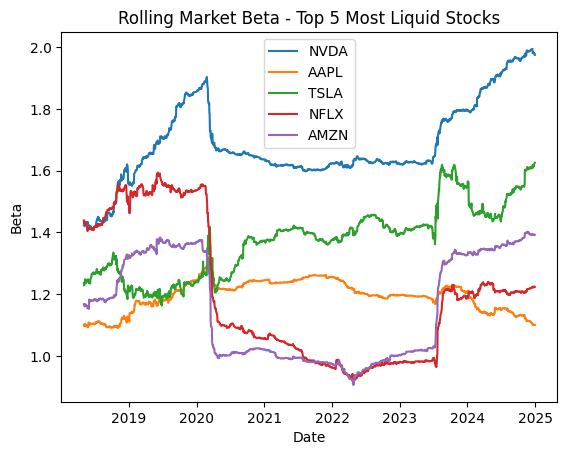

The window size is 838 days


In [16]:
# stock = stock_cols[0]  # arbitrary example, possible to change it to a different one
# data = rolling_df[rolling_df["Ticker"] == stock]
# plt.plot(data["Date"], data["Beta_Mkt"])

for stock in stock_cols[:5]: # top 5 most liquid stocks only
    data = rolling_df[rolling_df["Ticker"] == stock]
    plt.plot(data["Date"], data["Beta_Mkt"], label=stock)

plt.title(f"Rolling Market Beta - Top 5 Most Liquid Stocks")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.show()
print(f"The window size is {window} days")

The window is set to max(126, T//3) = 838 days (3.3 years).

The 126-day floor ensures enough observations for a stable beta estimate. The T//3 term ensures the window 
covers a substantial portion of the sample, here roughly one full market regime.

<a id="portfolio-risk-decomposition"></a>
## 4. Portfolio Risk Decomposition

<a id="systematic-vs-idiosyncratic-risk"></a>
### 4.1 Systematic vs Idiosyncratic Risk

In [17]:
equal_weights = np.ones(len(top30_tickers)) / len(top30_tickers)
cov_matrix = returns.cov() * 252
# sns.heatmap(returns.corr(), center=0, cmap="coolwarm");
print(f"Portfolio Variance: {round(equal_weights.T @ cov_matrix @ equal_weights*100,2)}%")

Portfolio Variance: 4.74%


In [18]:
res = model_estimation.set_index("Ticker").loc[stock_cols]

B = res[["Beta_Mkt", "Beta_SMB", "Beta_HML"]].values
D = np.diag(res["Residual_Var"].values * 252)
Sigma_f = df[["Mkt-RF", "SMB", "HML"]].cov().values * 252 # Calculating on "df", not "factors" -> to have the same time frame
w = equal_weights


var_systematic = w @ B @ Sigma_f @ B.T @ w
var_idiosyncratic = w @ D @ w

var_total = var_systematic + var_idiosyncratic

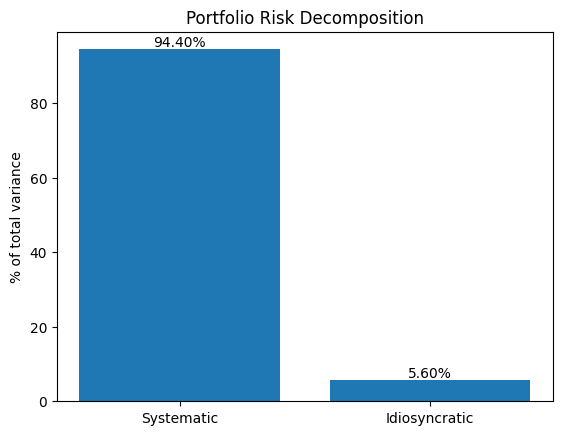

In [19]:
pct_systematic = var_systematic / var_total * 100
pct_idiosyncratic = var_idiosyncratic / var_total * 100

labels = ['Systematic', 'Idiosyncratic']

bars = plt.bar(labels, [pct_systematic, pct_idiosyncratic])

plt.ylabel('% of total variance')
plt.title('Portfolio Risk Decomposition')

plt.bar_label(bars, fmt='%.2f%%')

plt.show()

<a id="factor-risk-decomposition"></a>
### 4.2 Factor Risk Decomposition

In [20]:
Bw = B.T @ w
factor_contrib = Bw * (Sigma_f @ Bw)
factor_pct = factor_contrib / var_systematic * 100
factor_names = ["Market", "SMB", "HML"]

for f, pct in zip(factor_names, factor_pct):
    print(f"{f}: {pct:.2f}%")

Market: 99.95%
SMB: 0.15%
HML: -0.09%


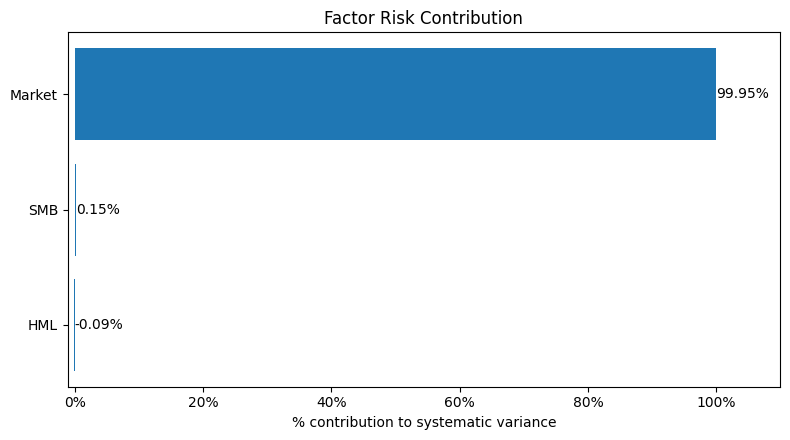

In [21]:
plot_df = pd.DataFrame({
    "Factor": factor_names,
    "Contribution": factor_pct
})

plot_df = plot_df.sort_values("Contribution")

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.barh(plot_df["Factor"], plot_df["Contribution"])

for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f"{width:.2f}%",
            va='center', ha='left')

ax.set_title("Factor Risk Contribution")
ax.set_xlabel("% contribution to systematic variance")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0f}%")

xmin = plot_df["Contribution"].min()
xmax = plot_df["Contribution"].max()

ax.set_xlim(xmin - 1, xmax + 10)

plt.tight_layout()
plt.show()

<a id="var-analysis"></a>
## 5. Value at Risk Analysis

<a id="var-calculations"></a>
### 5.1 VaR Calculations

<a id="historical-var"></a>
#### 5.1.1 Historical VaR

In [22]:
port_ret = returns @ w # w defined previously, here it's an equal weighted portfolio

# VaR
q_99 = np.quantile(port_ret, 0.01)
q_95 = np.quantile(port_ret, 0.05)

VaR_99 = -q_99
VaR_95 = -q_95

# CVaR (ES)
CVaR_99 = -port_ret[port_ret <= q_99].mean()
CVaR_95 = -port_ret[port_ret <= q_95].mean()

print(f"Daily VaR 95%: {VaR_95:.2%} | Daily VaR 99%: {VaR_99:.2%}")
print(f"Daily CVaR 95%: {CVaR_95:.2%} | Daily CVaR 99%: {CVaR_99:.2%}")

Daily VaR 95%: 2.10% | Daily VaR 99%: 3.82%
Daily CVaR 95%: 3.29% | Daily CVaR 99%: 5.39%


<a id="parametric-var"></a>
#### 5.1.2 Parametric VaR

In [23]:
Sigma_f_daily = df[["Mkt-RF", "SMB", "HML"]].cov().values
D_daily = np.diag(res["Residual_Var"].values)
Sigma_daily = B @ Sigma_f_daily @ B.T + D_daily

mu_p = (returns @ w).mean()
sigma_p = np.sqrt(w.T @ Sigma_daily @ w)

# Using a normal distribution (not printed as it's the nu -> inf case in the summary table)
VaR_99p_n = -(mu_p + norm.ppf(0.01) * sigma_p)
VaR_95p_n = -(mu_p + norm.ppf(0.05) * sigma_p)

# Using a student t distribution
nus = [4, 5, 8, 20]
nu_table = []

for nu in nus:
    scale = np.sqrt((nu - 2) / nu)
    
    VaR_95p_t = -(mu_p + t.ppf(0.05, df=nu) * sigma_p * scale)
    VaR_99p_t = -(mu_p + t.ppf(0.01, df=nu) * sigma_p * scale)
    
    nu_table.append([VaR_95p_t, VaR_99p_t])

nu_table.append([VaR_95p_n, VaR_99p_n])
index = [f"v={nu}" for nu in nus] + ["v -> inf"]

nu_table = pd.DataFrame(
    nu_table,
    index=index,
    columns=["VaR 95%", "VaR 99%"]
)

table = nu_table.map(lambda x: f"{x:.2%}")
table.index.name = "df"
table

,VaR 95%,VaR 99%
df,,
v=4,1.96%,3.51%
v=5,2.03%,3.45%
v=8,2.10%,3.32%
v=20,2.13%,3.17%
v -> inf,2.14%,3.07%


<a id="stressed-var"></a>
#### 5.1.3 Stressed VaR

In [24]:
# VaR
covid_window = port_ret.loc["2020-02-19":"2020-05-15"]

q_99_covid = np.quantile(covid_window, 0.01)
q_95_covid = np.quantile(covid_window, 0.05)
VaR_99_covid = -q_99_covid
VaR_95_covid = -q_95_covid

# CVaR (ES)
CVaR_99_covid = -covid_window[covid_window <= q_99_covid].mean()
CVaR_95_covid = -covid_window[covid_window <= q_95_covid].mean()

print(f"Stressed Daily VaR 95%:  {VaR_95_covid:.2%} | Stressed Daily VaR 99%:  {VaR_99_covid:.2%}")
print(f"Stressed Daily CVaR 95%: {CVaR_95_covid:.2%} | Stressed Daily CVaR 99%: {CVaR_99_covid:.2%}")

Stressed Daily VaR 95%:  6.95% | Stressed Daily VaR 99%:  11.83%
Stressed Daily CVaR 95%: 10.04% | Stressed Daily CVaR 99%: 13.17%


In [25]:
var_comparison = pd.DataFrame({
    "Historical (full sample)": [VaR_95, VaR_99],
    "Parametric (normal)":      [VaR_95p_n, VaR_99p_n],
    "Parametric (t, v=5)":      [nu_table.loc["v=5"].values[0], nu_table.loc["v=5"].values[1]],
    "Stressed (COVID)":         [VaR_95_covid, VaR_99_covid],  # add VaR_99_covid too
}, index=["VaR 95%", "VaR 99%"]).map(lambda x: f"{x:.2%}" if isinstance(x, float) else x)

var_comparison

,Historical (full sample),Parametric (normal),"Parametric (t, v=5)",Stressed (COVID)
VaR 95%,2.10%,2.14%,2.03%,6.95%
VaR 99%,3.82%,3.07%,3.45%,11.83%


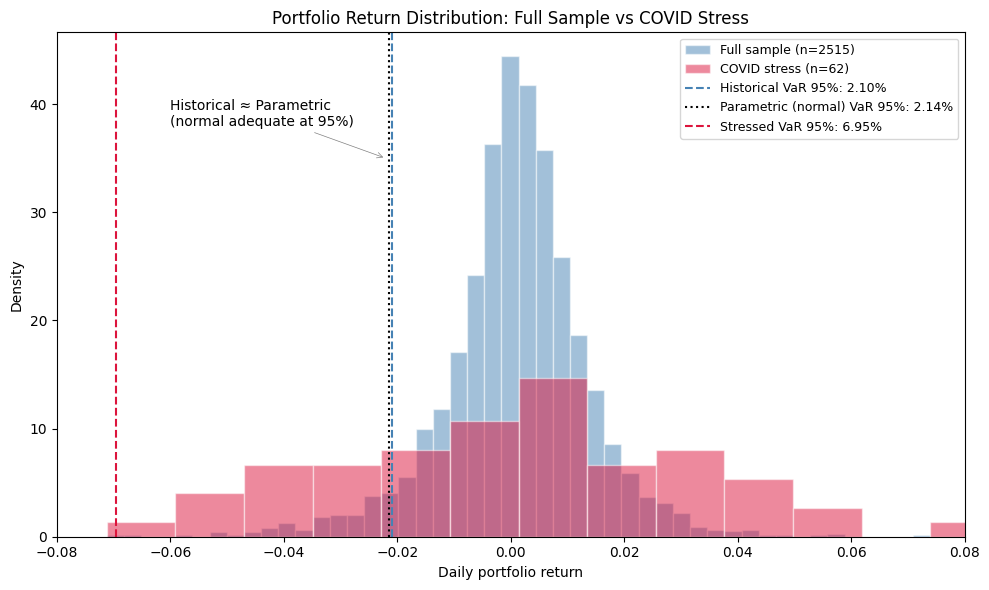

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(port_ret, bins=80, density=True, alpha=0.5, color="steelblue",
        label=f"Full sample (n={len(port_ret)})", edgecolor="white")

ax.hist(covid_window, bins=20, density=True, alpha=0.5, color="crimson",
        label=f"COVID stress (n={len(covid_window)})", edgecolor="white")

ax.axvline(-VaR_95,       color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Historical VaR 95%: {VaR_95:.2%}")
ax.axvline(-VaR_95p_n,    color="black",     linestyle=":",  linewidth=1.5,
           label=f"Parametric (normal) VaR 95%: {VaR_95p_n:.2%}")
ax.axvline(-VaR_95_covid, color="crimson",   linestyle="--", linewidth=1.5,
           label=f"Stressed VaR 95%: {VaR_95_covid:.2%}")

ax.annotate("Historical ≈ Parametric\n(normal adequate at 95%)",
            xy=(-0.022, 35), xytext=(-0.06, 38),
            fontsize=10, ha="left",
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))

ax.set_xlim(-0.08, 0.08)
ax.set_xlabel("Daily portfolio return")
ax.set_ylabel("Density")
ax.set_title("Portfolio Return Distribution: Full Sample vs COVID Stress")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

<a id="backtesting"></a>
### 5.2 Backtesting

Var Kupiec Proportion of Failures test

In [27]:
def kupiec_pof(returns, VaR, p, alpha=0.05):
    """
    Kupiec Proportion of Failures test.
    
    returns : pd.Series of portfolio returns (not losses)
    VaR     : positive float, VaR estimate (e.g., 0.021 for 2.1%)
    p       : tail probability (0.01 for VaR 99%, 0.05 for VaR 95%)
    """
    T = len(returns)
    violations = (returns < -VaR)
    N = violations.sum()
    p_hat = N / T
    
    if N == 0:
        LR = -2 * T * np.log(1 - p)
    elif N == T:
        LR = -2 * T * np.log(p)
    else:
        LR = -2 * (
            N * np.log(p) + (T - N) * np.log(1 - p)
            - N * np.log(p_hat) - (T - N) * np.log(1 - p_hat)
        )
    
    p_value = 1 - chi2.cdf(LR, df=1)
    crit = chi2.ppf(1 - alpha, df=1)
    reject = LR > crit
    
    return {
        "T": T, "N": N,
        "expected": p * T,
        "violation_rate": p_hat,
        "LR": LR,
        "p_value": p_value,
        "reject_H0": reject,
    }

In [28]:
var_models = pd.DataFrame({
    "VaR":   [VaR_95, VaR_99, VaR_95p_n, VaR_99p_n, VaR_95p_t, VaR_99p_t],
    "level": [0.05,   0.01,   0.05,      0.01,      0.05,      0.01],
    }, index=["Historical 95%", "Historical 99%",
          "Parametric normal 95%", "Parametric normal 99%",
          "Parametric t(5) 95%", "Parametric t(5) 99%"])

T = len(port_ret)
rows = []

for name, row in var_models.iterrows():
    VaR, p = row["VaR"], row["level"]
    N = (port_ret < -VaR).sum()
    p_hat = N / T
    LR = -2 * (N*np.log(p) + (T-N)*np.log(1-p) - N*np.log(p_hat) - (T-N)*np.log(1-p_hat))
    rows.append([T, N, p*T, p_hat, LR, 1 - chi2.cdf(LR, df=1)])

pof_results = pd.DataFrame(rows, index=var_models.index, columns=["T", "N", "expected", "violation_rate", "Likelihood Ratio", "p_value"])
pof_results

,T,N,expected,violation_rate,Likelihood Ratio,p_value
Historical 95%,2515,126,125.75,0.050099,0.000523,9.817573e-01
Historical 99%,2515,26,25.15,0.010338,0.028700,8.654746e-01
Parametric normal 95%,2515,120,125.75,0.047714,0.280851,5.961440e-01
Parametric normal 99%,2515,54,25.15,0.021471,25.161209,5.273226e-07
Parametric t(5) 95%,2515,121,125.75,0.048111,0.191163,6.619501e-01
Parametric t(5) 99%,2515,49,25.15,0.019483,17.891505,2.338627e-05


In [29]:
failed = pof_results.index[pof_results["p_value"] < 0.05].tolist()
print(f"The following models do not pass the Kupiec test:\n" + "\n".join(f"• {m}" for m in failed))

The following models do not pass the Kupiec test:
• Parametric normal 99%
• Parametric t(5) 99%


At the 99% level, the parametric models do not pass the Kupiec test. Both the normal and the t(5) versions show too many violations compared to expectations.

This reflects a well-known feature of equity returns. They exhibit fat tails. Parametric assumptions struggle to capture this behavior.

As a result, these models underestimate extreme risk. Historical simulation is therefore more reliable for estimating 99% VaR.

<a id="stress-scenarios"></a>
## 6. Factor Stress Scenarios

In [30]:
scenario_names = ["GFC replay", "Rates & inflation shock", "Flight to quality"]

scenarios = pd.DataFrame({
    "Mkt-RF": [-0.35, -0.15, -0.20],
    "SMB":    [-0.15, -0.05,  0.00],
    "HML":    [ 0.10,  0.05, -0.05],
}, index=scenario_names)
scenarios

,Mkt-RF,SMB,HML
GFC replay,-0.35,-0.15,0.10
Rates & inflation shock,-0.15,-0.05,0.05
Flight to quality,-0.20,0.00,-0.05


In [31]:
port_betas = B.T @ w
pd.Series(port_betas, index=["Mkt-RF", "SMB", "HML"]).to_frame("Portfolio betas").style.format("{:.3f}")

,Portfolio betas
Mkt-RF,1.145
SMB,0.013
HML,0.034


The model provides coherent answers but should be taken with a grain of salt as betas aren't stable during a crisis

 In a GFC-type event, market beta would likely have risen above 1.145 as correlations spiked, making the -39.95% estimate a floor rather than a point estimate

In [32]:
contrib = scenarios.values * port_betas
contrib_df = pd.DataFrame(contrib, index=scenarios.index, columns=scenarios.columns)
contrib_df["Total P&L"] = contrib_df.sum(axis=1)

contrib_df.style.format("{:.2%}")

,Mkt-RF,SMB,HML,Total P&L
GFC replay,-40.09%,-0.20%,0.34%,-39.95%
Rates & inflation shock,-17.18%,-0.07%,0.17%,-17.08%
Flight to quality,-22.91%,0.00%,-0.17%,-23.08%
